# Predicting Customer Churn in Telecommunications

## Research Question
What factors most strongly predict customer churn in a telecommunications company, and can we build a model to identify at-risk customers before they leave?

## Dataset
Telco Customer Churn Dataset from Kaggle: 7,043 customer records with 21 features including demographics, account information, and service subscriptions.

---


## 1. Setup and Data Acquisition


In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


In [45]:
# Load the dataset
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(f"Dataset downloaded to: {path}")

import os
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_file)
print(f"\nDataset shape: {df.shape}")


Dataset downloaded to: /Users/sameer/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1

Dataset shape: (7043, 21)


In [46]:
# Initial data inspection
print("First 5 rows:")
df.head()


First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
# Data types and info
print("Data Types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Check for empty strings in TotalCharges
empty_tc = (df['TotalCharges'].str.strip() == '').sum()
print(f"Empty strings in TotalCharges: {empty_tc}")


Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values: 0
Empty strings in TotalCharges: 11


## 2. Exploratory Data Analysis


In [48]:
# Fix TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaN values: {df['TotalCharges'].isnull().sum()}")

# Check these rows
missing_tc = df[df['TotalCharges'].isnull()]
print(f"\nRows with missing TotalCharges:")
print(f"  Tenure values: {missing_tc['tenure'].unique().tolist()}")
print(f"  Churn values: {missing_tc['Churn'].unique().tolist()}")


TotalCharges NaN values: 11

Rows with missing TotalCharges:
  Tenure values: [0]
  Churn values: ['No']


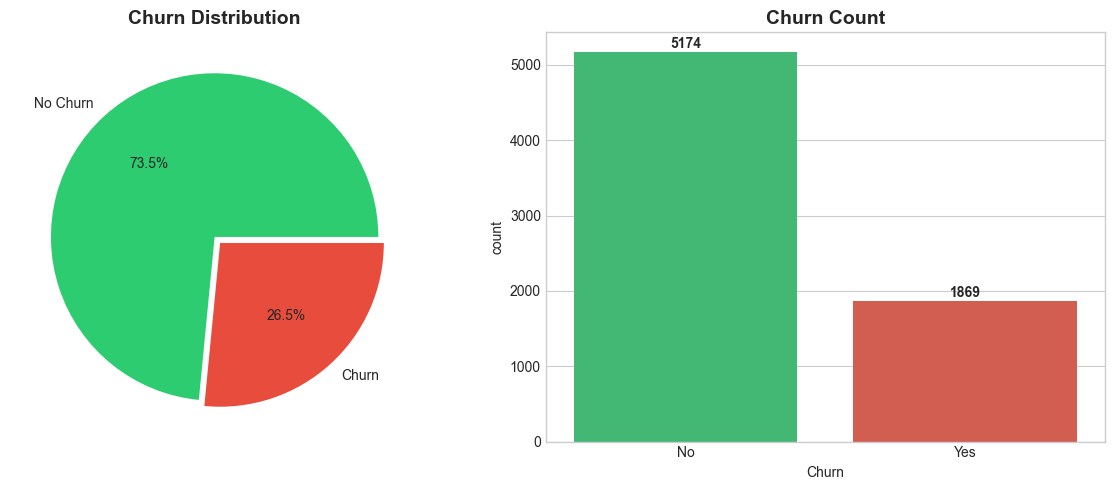

Churn Rate: 26.54%


In [49]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=colors, explode=[0, 0.05])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Churn', palette=colors, ax=axes[1])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Churn Rate: {(df['Churn'] == 'Yes').mean()*100:.2f}%")


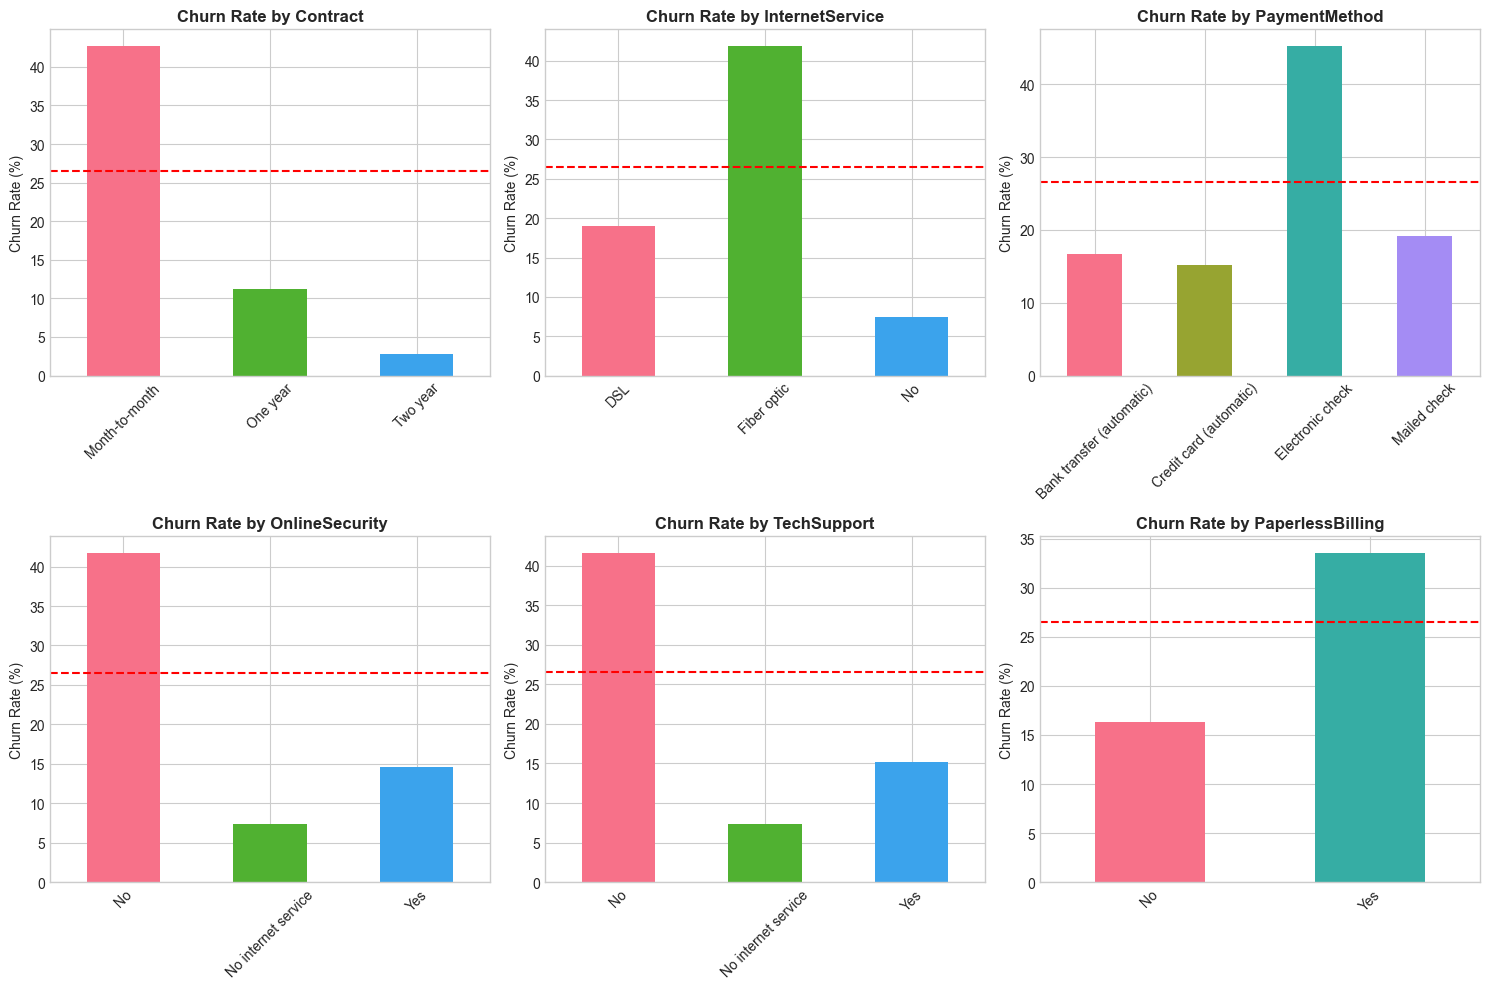

In [50]:
# Churn by key categorical features
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

key_features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    churn_rate = df.groupby(feature)['Churn_Binary'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color=sns.color_palette('husl', len(churn_rate)))
    ax.set_title(f'Churn Rate by {feature}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=26.54, color='red', linestyle='--', label='Overall Rate')

plt.tight_layout()
plt.show()


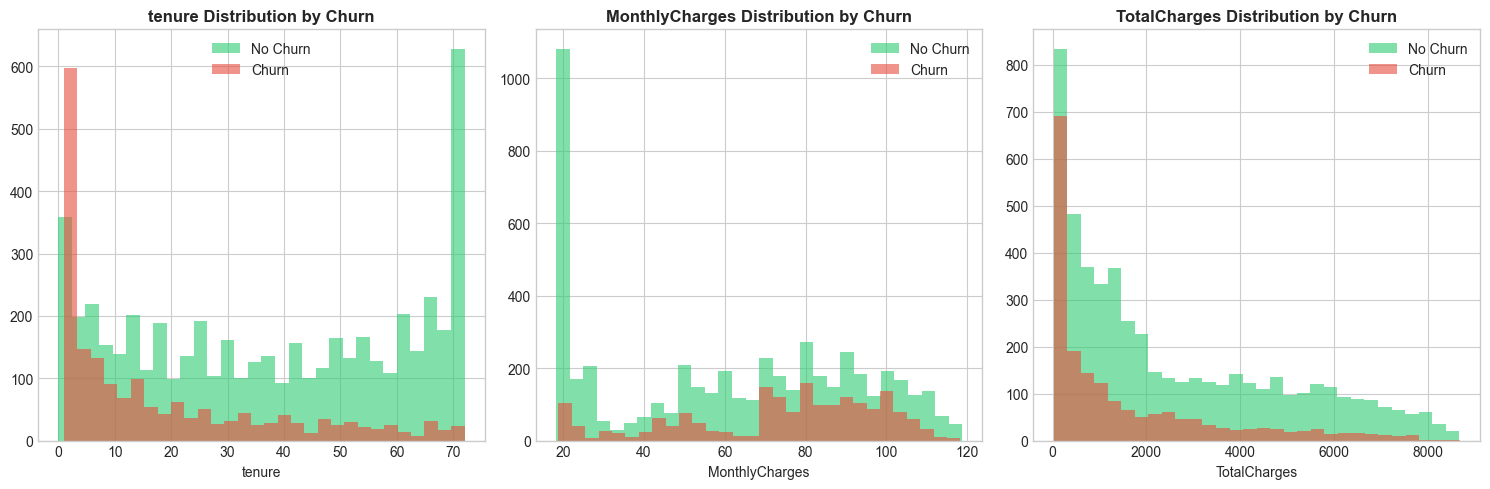

In [51]:
# Numeric feature distributions by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]
    for churn_val, color, label in [('No', '#2ecc71', 'No Churn'), ('Yes', '#e74c3c', 'Churn')]:
        subset = df[df['Churn'] == churn_val][feature].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color)
    ax.set_title(f'{feature} Distribution by Churn', fontweight='bold')
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout()
plt.show()


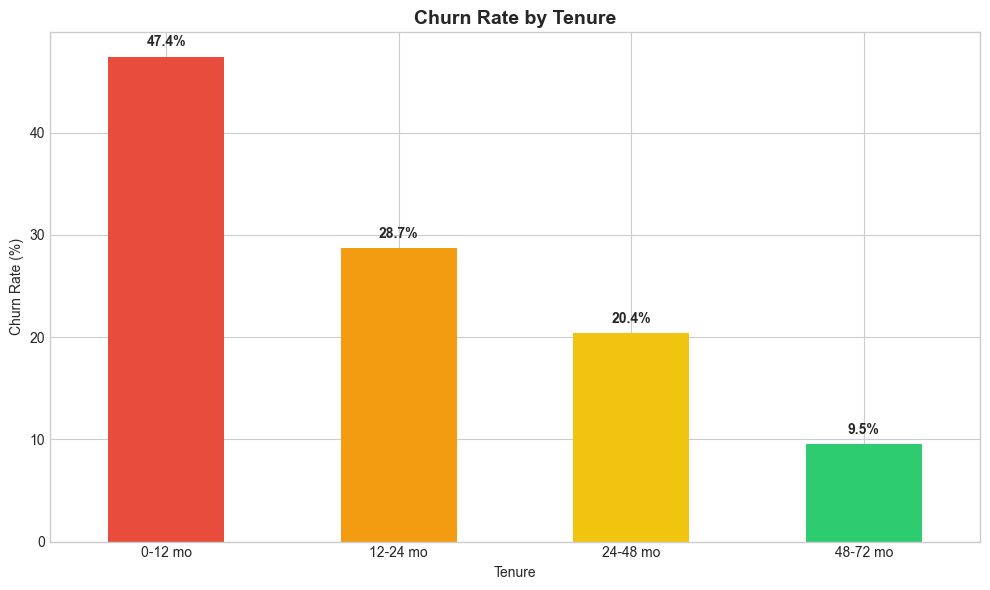

In [52]:
# Churn rate by tenure buckets
df['tenure_bucket'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 mo', '12-24 mo', '24-48 mo', '48-72 mo'],
                             include_lowest=True)

fig, ax = plt.subplots(figsize=(10, 6))
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn_Binary'].mean() * 100
tenure_churn.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71'])
ax.set_title('Churn Rate by Tenure', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(tenure_churn):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


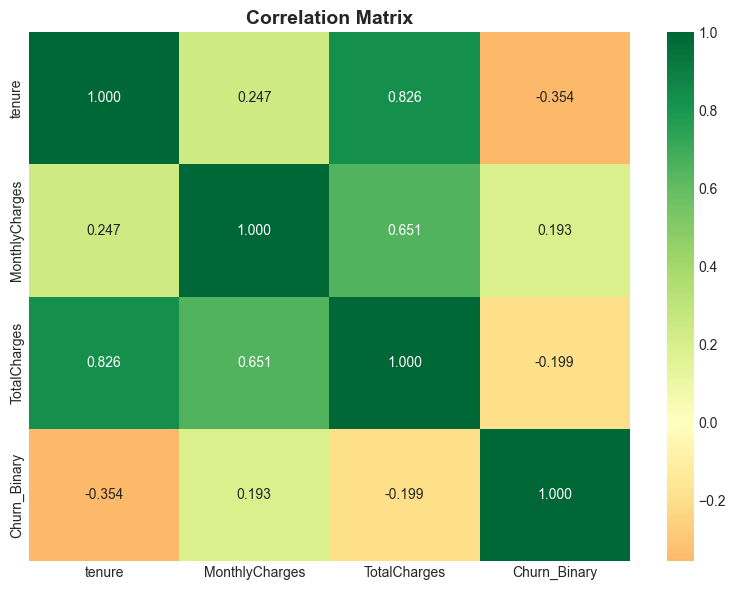

In [53]:
# Correlation heatmap
df_numeric = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, ax=ax, fmt='.3f')
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


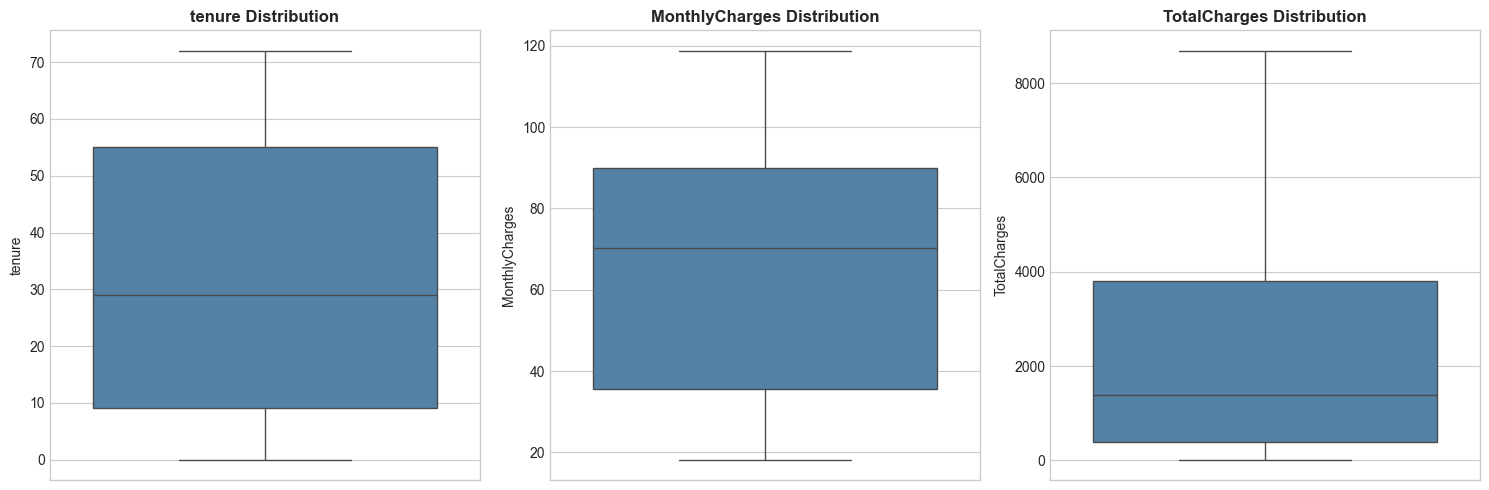

Outlier Analysis Summary (IQR Method):
       Feature     Q1        Q3       IQR  Lower Bound  Upper Bound  Outliers  Outlier %
        tenure   9.00   55.0000   46.0000    -60.00000    124.00000         0        0.0
MonthlyCharges  35.50   89.8500   54.3500    -46.02500    171.37500         0        0.0
  TotalCharges 401.45 3794.7375 3393.2875  -4688.48125   8884.66875         0        0.0

Conclusion: No significant outliers requiring removal. The data distributions are expected for this domain.


In [54]:
# Outlier Analysis using IQR method
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

outlier_summary = []
for idx, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Box plot
    sns.boxplot(y=data, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_ylabel(col)
    
    # Calculate IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers': len(outliers),
        'Outlier %': len(outliers) / len(data) * 100
    })

plt.tight_layout()
plt.show()

# Display outlier summary
outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Analysis Summary (IQR Method):")
print(outlier_df.to_string(index=False))
print("\nConclusion: No significant outliers requiring removal. The data distributions are expected for this domain.")


## 3. Data Preprocessing


In [55]:
# Start fresh
df_clean = pd.read_csv(csv_file)

# Convert TotalCharges and fill missing with 0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# Drop customerID
df_clean = df_clean.drop('customerID', axis=1)

# Encode target
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

print(f"Shape after cleaning: {df_clean.shape}")


Shape after cleaning: (7043, 20)


In [56]:
# Identify feature types
from sklearn.preprocessing import LabelEncoder

target = 'Churn'
features = [col for col in df_clean.columns if col != target]

numeric_features = df_clean[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_clean[features].select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Encode binary features
binary_features = [col for col in categorical_features if df_clean[col].nunique() == 2]
multi_features = [col for col in categorical_features if df_clean[col].nunique() > 2]

le = LabelEncoder()
for col in binary_features:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-hot encode multi-class features
df_encoded = pd.get_dummies(df_clean, columns=multi_features, drop_first=False)

print(f"\nShape after encoding: {df_encoded.shape}")


Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 41)


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

# Scale numeric features
features_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("\nScaling complete.")


Train set: 5634 samples
Test set: 1409 samples
Train churn rate: 26.54%
Test churn rate: 26.54%

Scaling complete.


## 4. Model Building


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model 1: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

# Model 2: Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# Model 3: Gradient Boosting
print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
# Calculate sample weights
class_counts = y_train.value_counts()
weight_0 = len(y_train) / (2 * class_counts[0])
weight_1 = len(y_train) / (2 * class_counts[1])
sample_weights = y_train.map({0: weight_0, 1: weight_1})
gb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
gb_pred = gb_model.predict(X_test_scaled)
print(f"Gradient Boosting Test Accuracy: {accuracy_score(y_test, gb_pred):.4f}")


Training Logistic Regression...
Logistic Regression Test Accuracy: 0.7381

Training Random Forest...
Random Forest Test Accuracy: 0.7686

Training Gradient Boosting...
Gradient Boosting Test Accuracy: 0.7495


## 5. Model Evaluation


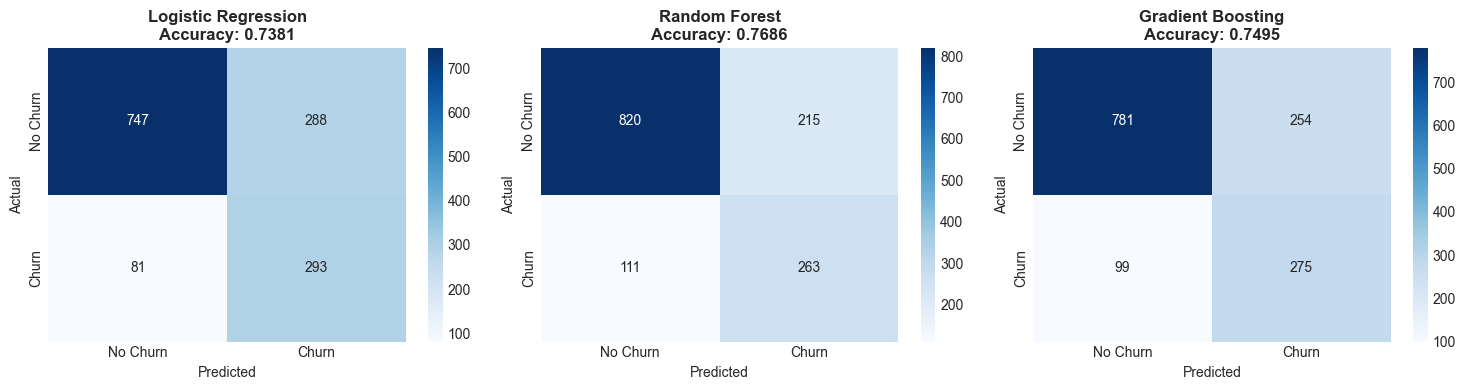

In [59]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Logistic Regression', lr_pred, lr_model),
    ('Random Forest', rf_pred, rf_model),
    ('Gradient Boosting', gb_pred, gb_model)
]

for idx, (name, pred, model) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.4f}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


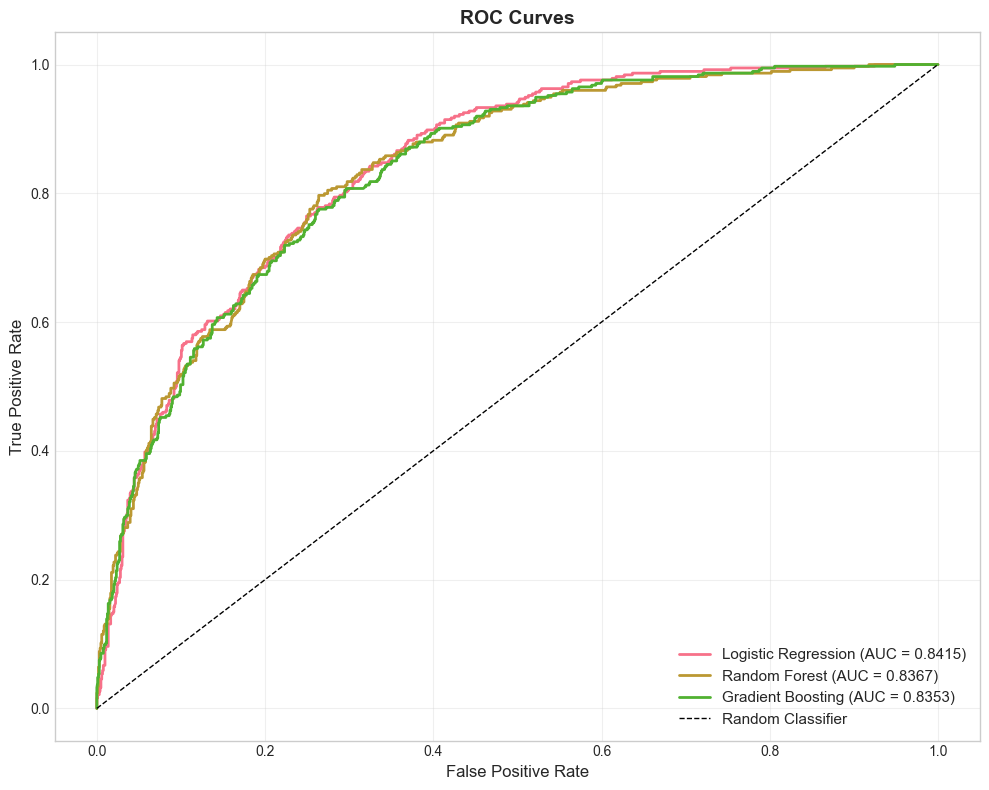

In [60]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, pred, model in models:
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [61]:
# Comprehensive metrics comparison
results = []
for name, pred, model in models:
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results)
print("Model Comparison:")
results_df


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841489
1,Random Forest,0.768630,0.550209,0.703209,0.617371,0.836697
2,Gradient Boosting,0.749468,0.519849,0.735294,0.609081,0.835311


In [62]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, _, model in models:
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'CV Accuracy Mean': cv_acc.mean(),
        'CV Accuracy Std': cv_acc.std(),
        'CV ROC-AUC Mean': cv_auc.mean(),
        'CV ROC-AUC Std': cv_auc.std()
    })

cv_df = pd.DataFrame(cv_results)
print("Cross-Validation Results:")
cv_df


Cross-Validation Results:


,Model,CV Accuracy Mean,CV Accuracy Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.748670,0.015358,0.846021,0.012412
1,Random Forest,0.780088,0.010916,0.843474,0.008342
2,Gradient Boosting,0.793930,0.010910,0.838570,0.007867


## 6. Feature Importance Analysis


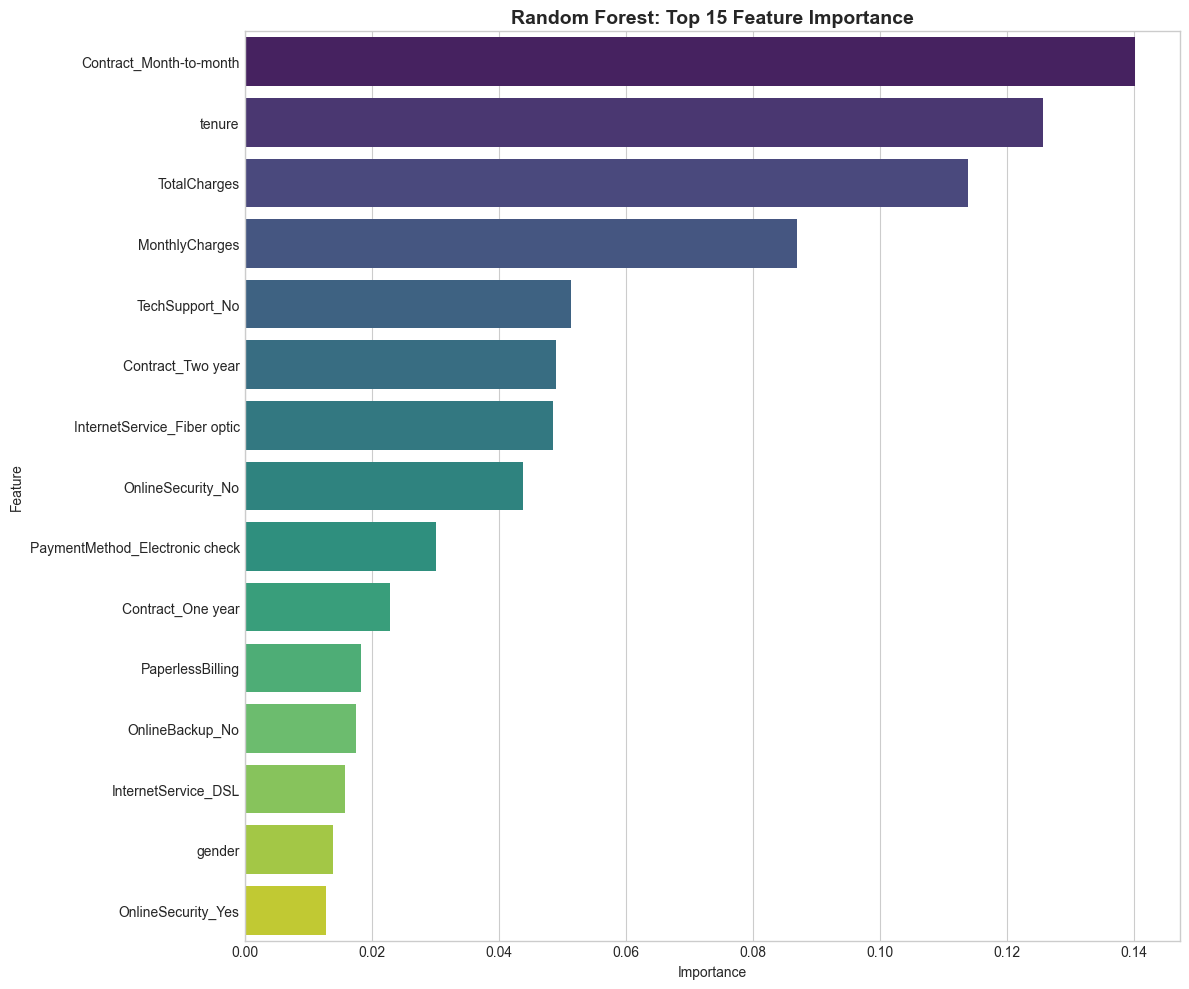

In [63]:
# Random Forest feature importance
feature_names = X_train_scaled.columns.tolist()

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_15 = rf_importance.head(15)
sns.barplot(data=top_15, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Random Forest: Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


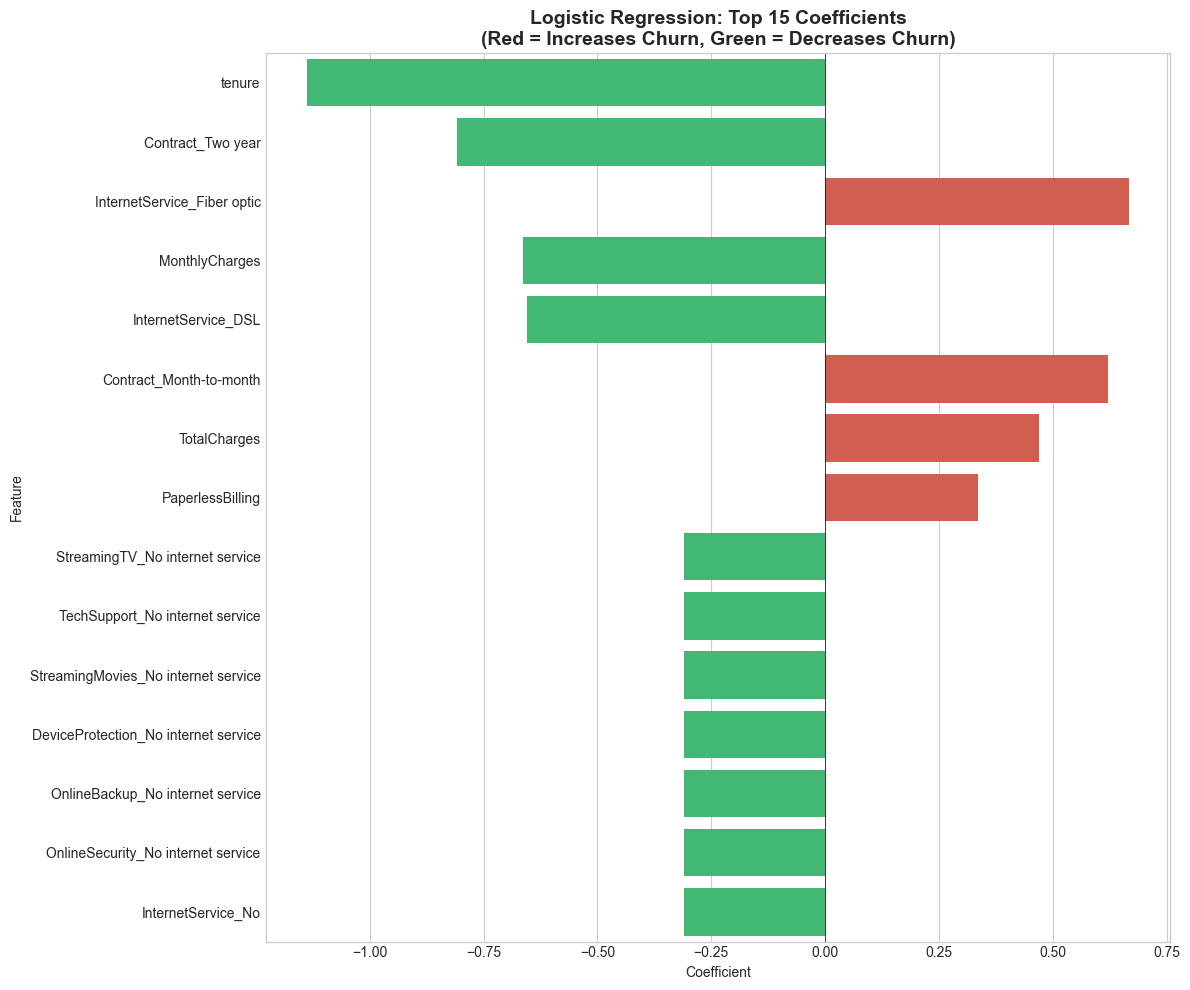

In [64]:
# Logistic Regression coefficients
lr_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})
lr_coefs['Abs_Coefficient'] = np.abs(lr_coefs['Coefficient'])
lr_coefs = lr_coefs.sort_values('Abs_Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_15_lr = lr_coefs.head(15)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_15_lr['Coefficient']]
sns.barplot(data=top_15_lr, x='Coefficient', y='Feature', palette=colors, ax=ax)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Logistic Regression: Top 15 Coefficients\n(Red = Increases Churn, Green = Decreases Churn)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


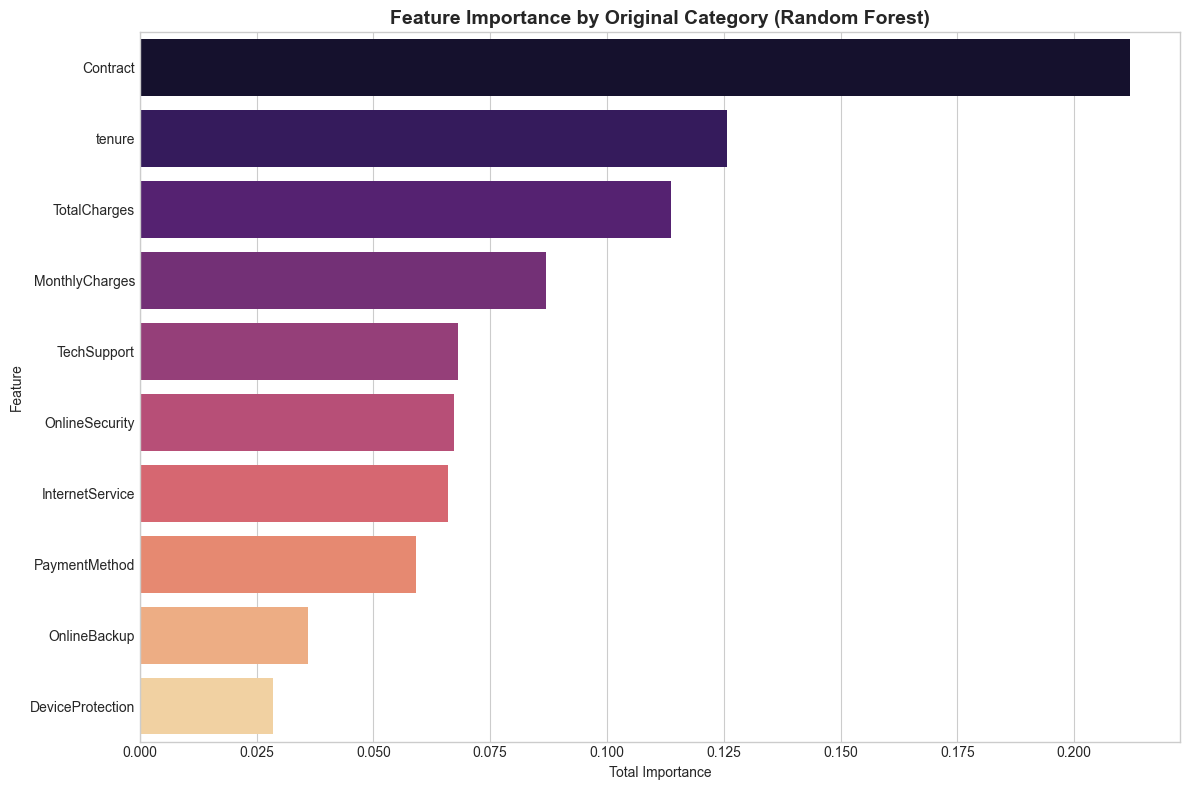


Top 7 Key Factors Influencing Churn:
  1. Contract (importance: 0.2121)
  2. tenure (importance: 0.1257)
  3. TotalCharges (importance: 0.1138)
  4. MonthlyCharges (importance: 0.0869)
  5. TechSupport (importance: 0.0681)
  6. OnlineSecurity (importance: 0.0674)
  7. InternetService (importance: 0.0660)


In [65]:
# Group features by original category
original_features = {}
prefixes = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaymentMethod']

for feat in feature_names:
    base = feat
    for prefix in prefixes:
        if feat.startswith(prefix + '_'):
            base = prefix
            break
    if base not in original_features:
        original_features[base] = []
    original_features[base].append(feat)

# Sum importance by original feature
original_importance = {}
for base, feats in original_features.items():
    importance = rf_importance[rf_importance['Feature'].isin(feats)]['Importance'].sum()
    original_importance[base] = importance

original_imp_df = pd.DataFrame({
    'Feature': list(original_importance.keys()),
    'Importance': list(original_importance.values())
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=original_imp_df.head(10), x='Importance', y='Feature', palette='magma', ax=ax)
ax.set_title('Feature Importance by Original Category (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Importance')
plt.tight_layout()
plt.show()

print("\nTop 7 Key Factors Influencing Churn:")
for i, (_, row) in enumerate(original_imp_df.head(7).iterrows(), 1):
    print(f"  {i}. {row['Feature']} (importance: {row['Importance']:.4f})")


## 7. Conclusions and Recommendations

### Key Findings

**Model Performance:**
- Random Forest achieved the highest accuracy (76.86%)
- Logistic Regression: Best recall for churn (78.34%) and ROC-AUC (0.8415)
- All models show consistent performance across cross-validation folds

**Top 7 Churn Factors Identified:**
1. **Contract Type** - Month-to-month customers have 42.7% churn vs 2.8% for two-year contracts
2. **Tenure** - Customers with 0-12 months tenure have 47.4% churn rate
3. **Total Charges** - Correlated with tenure; lower total spend indicates higher churn risk
4. **Monthly Charges** - Higher monthly bills correlate with increased churn
5. **Tech Support** - Customers without tech support: 41.6% churn
6. **Online Security** - Customers without online security: 41.8% churn
7. **Internet Service Type** - Fiber optic customers: 41.9% churn vs 19% for DSL

### Business Recommendations

1. **Focus on New Customers** - The first 12 months are critical; implement onboarding programs
2. **Promote Long-term Contracts** - Offer incentives for one-year or two-year commitments
3. **Bundle Security Services** - Customers with OnlineSecurity and TechSupport churn less
4. **Review Fiber Optic Pricing/Service** - High churn despite premium pricing suggests dissatisfaction
5. **Electronic Check Payment Flag** - Customers using electronic check have 45.3% churn rate

### Model Deployment Recommendation
For production use, Logistic Regression is recommended due to:
- Highest recall (78.34%) - catches more at-risk customers
- Highest ROC-AUC (0.8415) - best overall discrimination
- Interpretable coefficients for business understanding
- Fast prediction times
